# ***Loading data***

In [4]:
from sklearn.datasets import load_wine
import pandas as pd
wine = load_wine()
df = pd.DataFrame(wine.data,columns=wine.feature_names)
df['target'] = wine.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


# checking null **values**

In [5]:
df.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


# **Ploting Heatmap**

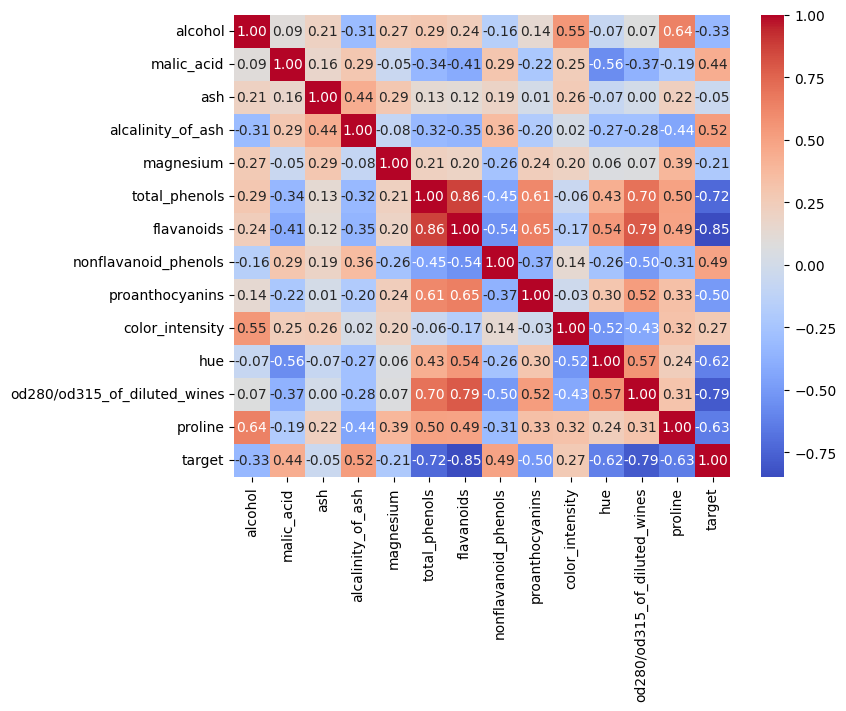

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.show()

# **split the data and the target column**

In [7]:
x = df.drop('target',axis=1)
y = df['target']

,target
0,0
1,0
2,0
3,0
4,0
...,...
173,2
174,2
175,2
176,2


# Train test **split**

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=43)

# **Standerdize the data**

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [16]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# **Building ANN**

In [28]:
modell = Sequential()
modell.add(Dense(16,activation='relu',input_dim=x_train_scaled.shape[1]))
modell.add(Dense(8,activation='relu'))
modell.add(Dense(3,activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **compile model**

In [29]:
modell.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
modell.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 387 (1.51 KB)

 Trainable params: 387 (1.51 KB)

 Non-trainable params: 0 (0.00 B)

# **Train model**

In [30]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)
history = modell.fit(x_train_scaled,y_train,epochs=100,batch_size=8,validation_split=0.2,callbacks=[early_stop])

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3451 - loss: 1.2021 - val_accuracy: 0.5172 - val_loss: 1.0818
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4425 - loss: 1.0947 - val_accuracy: 0.5862 - val_loss: 1.0283
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5221 - loss: 1.0079 - val_accuracy: 0.6552 - val_loss: 0.9796
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6283 - loss: 0.9240 - val_accuracy: 0.6897 - val_loss: 0.9309
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7168 - loss: 0.8549 - val_accuracy: 0.6897 - val_loss: 0.8850
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7522 - loss: 0.7908 - val_accuracy: 0.7586 - val_loss: 0.8408
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7788 - loss: 0.7324 - val_accuracy: 0.7931 - val_loss: 0.7938
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7876 - loss: 0.6795 - val_accuracy: 0.7931 - 

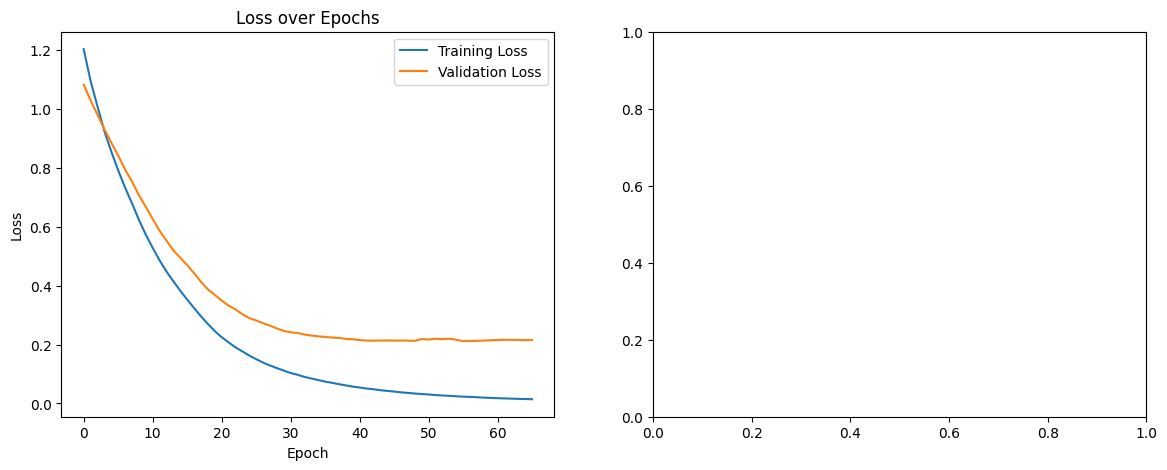

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# **prediction**

In [32]:
y_pred = modell.predict(x_test_scaled)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


In [34]:
import numpy as np
y_pred_class = np.argmax(y_pred,axis=1)

In [35]:
from sklearn.metrics import confusion_matrix,classification_report
print(confusion_matrix(y_test,y_pred_class))
print(classification_report(y_test,y_pred_class))

[[13  1  0]
 [ 0 13  1]
 [ 0  1  7]]
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.87      0.93      0.90        14
           2       0.88      0.88      0.88         8

    accuracy                           0.92        36
   macro avg       0.91      0.91      0.91        36
weighted avg       0.92      0.92      0.92        36



In [20]:
df.shape

(178, 14)